In [36]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner
import pandas as pd
from scipy import interpolate

In [37]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

# Constants

In [38]:
# List of atmoic numbers
A_dict = {'H' : 1.00797 ,
'He' : 4.00260 ,
'Li' : 6.941 ,
'Be' : 9.01218 ,
'B' : 10.81 ,
'C' : 12.011 ,
'N' : 14.0067 ,
'O' : 15.994 ,
'F' : 18.9994 ,
'Ne' : 20.179 ,
'Na' : 22.98977 ,
'Mg' : 24.305 ,
'Al' : 26.98154 ,
'Si' : 28.0855 ,
'P' : 30.97376 ,
'S' : 32.06 ,
'Cl' : 35.453 ,
'A' : 39.948 ,
'K' : 39.0983 ,
'Ca' : 40.08 ,
'Sc' : 44.9559 ,
'Ti' : 47.90 ,
'V' : 50.9415 ,
'Te' : 51.996 ,
'Mn' : 54.9380 ,
'Fe' : 55.847 ,
'Co' : 58.70 ,
'Ni' : 58.9332 ,
'Cu' : 63.546 ,
'Zn' : 65.38,
}

In [39]:
# Significance levels
# Sigma values taken from Gehrels 1986
cdf_1sig = 0.8413
cdf_2sig = 0.9772
cdf_3sig = 0.9987

In [40]:
# Boltzmann constant, adjusted to use km instead of m
k_B = 1.380649e-29
# Mass of hydrogen atom
amu = 1.66054e-27

# Functions

In [41]:
def gen_b(logT, b_NT, A):
    
    return np.sqrt((2*k_B*10**logT/(A*amu)) + b_NT**2)

In [42]:
def log_prior(params):

    # Grid parameters being varied
    logT, b_NT = params
    
    # Avoid edges?
    if 4<logT<6 and 0<b_NT<50:
        return 0.0
    return -np.inf

In [43]:
def log_likelihood(params, b_list):
    
    logT, b_NT = params

    #print(logT, b_NT)
    
    ll = 0
    
    for i in range(len(b_list)):
        
        ybar = gen_b(logT, b_NT, A_dict[b_list[i][1]])
        y = b_list[i][2]
        dy = b_list[i][3]
        
        ll += -.5*(y-ybar)**2/dy**2
            
    return ll

In [44]:
def log_probability(params, b_list):
        
    lp = log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, b_list)

In [45]:
gen_b(4, 0, A_dict['H'])

12.844232700646511

# z=0.67

In [46]:
b_list = [[['HI', 'H', 34, 2],
          ['CIII', 'C', 32, 2],
          ['CIV', 'C', 37, 6],
          ['OIII', 'O', 34, 2],
          ['OIV', 'O', 30, 2]]]

In [47]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [48]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [49]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:03<00:00, 137.57it/s]


State([[ 4.24819585 30.42113199]
 [ 4.06702153 29.85722305]
 [ 4.22671372 31.69841254]
 [ 4.52178147 30.10218166]
 [ 4.11561931 29.90408027]
 [ 4.0598166  30.99427005]
 [ 4.46138308 29.7002906 ]
 [ 4.05455292 31.89391196]
 [ 4.30752991 29.08625916]
 [ 4.46336741 29.43369445]
 [ 4.43873055 33.63471738]
 [ 4.02127437 31.11243702]
 [ 4.03692441 32.16484521]
 [ 4.26611614 30.2066663 ]
 [ 4.31908123 32.30944096]
 [ 4.38081553 29.29179753]
 [ 4.20472019 31.7670018 ]
 [ 4.09539469 30.60535698]
 [ 4.32126041 29.51765662]
 [ 4.37504443 29.73486784]
 [ 4.18292595 33.17861945]
 [ 4.10240721 31.42731804]
 [ 4.00617254 32.06963805]
 [ 4.25184512 31.3357473 ]
 [ 4.38571375 30.46174517]
 [ 4.19187991 33.05368252]
 [ 4.28138431 30.69535869]
 [ 4.01761276 31.46568276]
 [ 4.21478939 32.64462328]
 [ 4.05868074 30.12581383]
 [ 4.13879161 32.23999664]
 [ 4.10514414 32.14658673]
 [ 4.09994867 31.15218634]
 [ 4.2367726  29.70006802]
 [ 4.49182213 31.48997728]
 [ 4.05251731 31.76486599]
 [ 4.29112766 33.33038

In [50]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

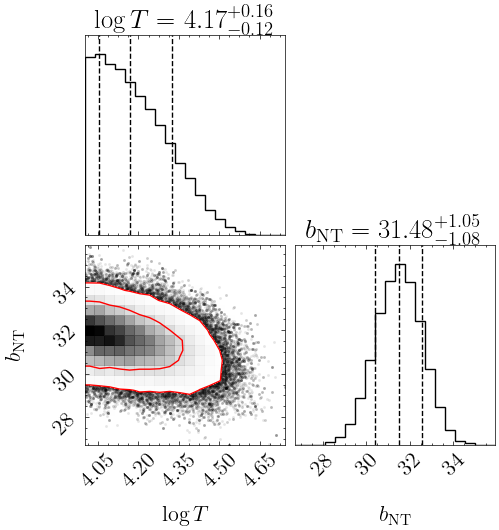

In [51]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [52]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

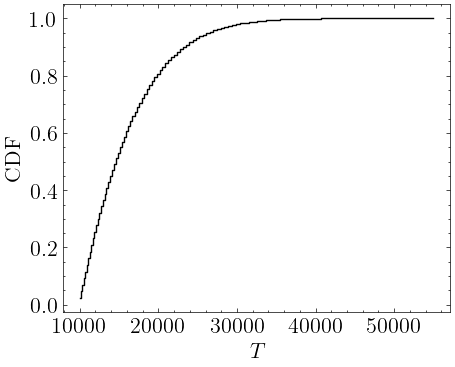

In [53]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [54]:
np.log10(ppf(cdf_3sig))

4.60106082083944

Predicted linewidths

In [55]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

31.832161817287705

In [56]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

31.78315320185248

In [57]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

31.746582926450188

In [58]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

31.69230978165107

In [59]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

31.657123623917187

In [60]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

31.640134761545628

In [61]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

31.633854140318554

In [62]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

31.615743612017422

In [63]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

31.55905011273638

# z=0.72

In [64]:
b_list = [[['HI', 'H', 25.6, 0.4],
          ['CIII', 'C', 16, 4],
          ['OIII', 'O', 13, 2]]]

In [65]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [66]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [67]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 181.56it/s]


State([[ 4.47035626 11.44481773]
 [ 4.51510775 10.32619445]
 [ 4.50654553 12.23570192]
 [ 4.52614682  9.72289469]
 [ 4.48887439 11.54326683]
 [ 4.43188198 12.58830705]
 [ 4.43913809 13.67498568]
 [ 4.48349948 12.09516798]
 [ 4.55465142  7.54301677]
 [ 4.42497926 14.5647252 ]
 [ 4.39347349 15.08016779]
 [ 4.42832122 13.2152911 ]
 [ 4.49186657 13.08905354]
 [ 4.43814649 13.3795467 ]
 [ 4.50125665 12.77265447]
 [ 4.50009131 11.16263565]
 [ 4.57806716  7.88382495]
 [ 4.47784357 12.39121799]
 [ 4.43341602 14.42946764]
 [ 4.47053935 13.21475886]
 [ 4.49635226 12.94499555]
 [ 4.50851751 11.6933448 ]
 [ 4.55111444  9.37861038]
 [ 4.37710335 15.56871843]
 [ 4.47577903 12.89818502]
 [ 4.35962204 15.99032275]
 [ 4.45792602 11.88179714]
 [ 4.39164846 16.14149808]
 [ 4.44602342 14.51457255]
 [ 4.55697612  6.6477211 ]
 [ 4.5234472  11.29104714]
 [ 4.43178072 13.87866143]
 [ 4.40866098 15.08251534]
 [ 4.44313648 12.85982332]
 [ 4.54876374 10.57464843]
 [ 4.52384194  8.92223946]
 [ 4.4579773  13.48549

In [68]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

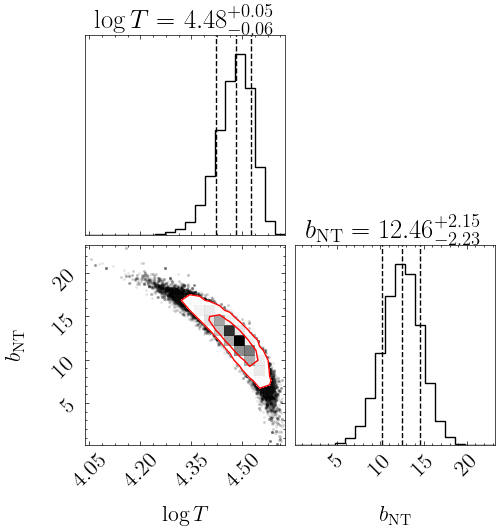

In [69]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [70]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

14.043701792488118

In [71]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

13.828942925677378

In [72]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

13.667011360829889

In [79]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

13.427005446653109

In [80]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

13.268024075699444

In [81]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

13.1900016619904

In [82]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

13.16236172343532

In [83]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

13.077986111690567

In [84]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

12.820329057017474

# z=1.09

In [126]:
b_list = [[['HI', 'H', 23, 3],
          ['CIV', 'C', 18.2, 0.3],
          ['NIV', 'N', 13, 7],
          ['OIII', 'O', 25, 2],
          ['OIV', 'O', 23, 1],
          ['OV', 'O', 26, 2]]]

In [127]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [128]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [129]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 120.66it/s]


State([[ 4.00117079 18.21549755]
 [ 4.05911967 18.40625978]
 [ 4.08247792 18.53538709]
 [ 4.0494092  18.38707684]
 [ 4.12833651 18.12965565]
 [ 4.33063341 18.28392667]
 [ 4.18573355 18.39048939]
 [ 4.13362469 18.36871919]
 [ 4.04105009 18.51576285]
 [ 4.08297248 18.39291235]
 [ 4.09104843 19.00429223]
 [ 4.1547625  18.161414  ]
 [ 4.0775782  18.17560762]
 [ 4.41263557 17.93993156]
 [ 4.2316961  17.86453226]
 [ 4.0356652  18.34606758]
 [ 4.05322987 19.04001842]
 [ 4.01951805 18.44885606]
 [ 4.12622807 18.11862563]
 [ 4.00064414 18.17082097]
 [ 4.19153583 18.80633722]
 [ 4.12006435 18.2620524 ]
 [ 4.04924453 18.4226305 ]
 [ 4.24799842 18.07015892]
 [ 4.04463896 18.54530239]
 [ 4.04231867 18.16178345]
 [ 4.18983821 17.57720656]
 [ 4.27155219 18.56329383]
 [ 4.01630526 18.57751686]
 [ 4.05449006 19.09136679]
 [ 4.00057667 18.34312095]
 [ 4.13725985 17.97369642]
 [ 4.08173057 18.68044598]
 [ 4.2349724  18.32286902]
 [ 4.01087578 18.52790545]
 [ 4.07910376 18.79794701]
 [ 4.07672061 18.06015

In [130]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

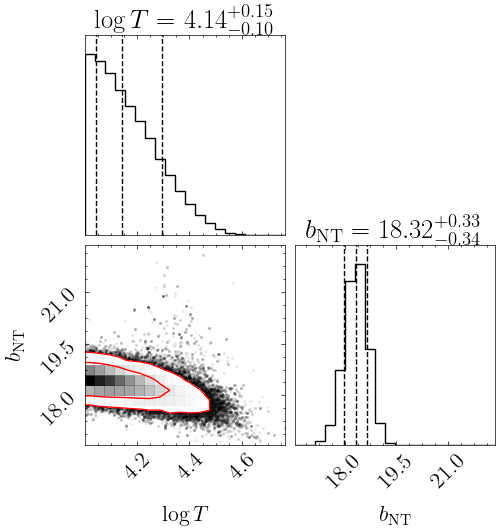

In [131]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [132]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

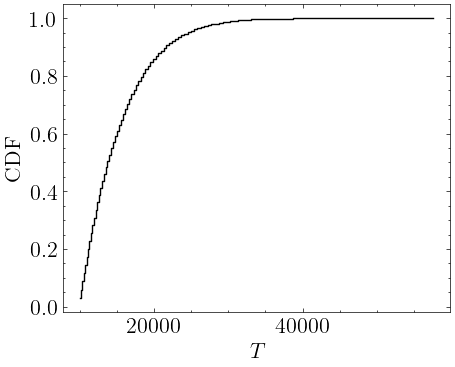

In [133]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [134]:
np.log10(ppf(cdf_3sig))

4.573539932707806

Predicted linewidths

In [135]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

19.917864152148898

In [136]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

18.876339041594377

In [137]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

18.79707916017271

In [138]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

18.737842728457515

In [139]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

18.650809632299854

In [140]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

18.5943542256674

In [141]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

18.567154477500285

In [142]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

18.557542107629658

In [143]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

18.527823737101627

In [144]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

18.439417055644146

# z=1.16, c1

In [193]:
b_list = [[['HI', 'H', 21.4, 0.9],
          ['HeI', 'He', 14, 1],
          ['CIV', 'C', 11.0, 0.4],
          ['OIII', 'O', 16, 3],
          ['OIV', 'O', 18, 2],
          ['OV', 'O', 11, 3]]]

In [194]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [195]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [196]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 113.86it/s]


State([[ 4.27283803 10.49856558]
 [ 4.27590882 10.02413347]
 [ 4.31223796 10.04624617]
 [ 4.2739612  10.49141046]
 [ 4.32190215 10.63068726]
 [ 4.2315373  10.39309417]
 [ 4.38421548  9.54241494]
 [ 4.32948611 10.28326856]
 [ 4.24174145 10.0119109 ]
 [ 4.34639447 10.06948669]
 [ 4.30163325 11.0093111 ]
 [ 4.29354105 11.23799004]
 [ 4.34488802  9.9628231 ]
 [ 4.39383479 10.1122688 ]
 [ 4.31742277 10.67688314]
 [ 4.39136027  9.13289876]
 [ 4.37093034  9.5720733 ]
 [ 4.32598095  8.92361479]
 [ 4.40237189  9.85523074]
 [ 4.3570349  10.41210225]
 [ 4.26522138 10.54061609]
 [ 4.34195118 10.4078558 ]
 [ 4.38202974  9.90855349]
 [ 4.24894149  9.78496003]
 [ 4.39642401  9.56093089]
 [ 4.31501381  9.2279391 ]
 [ 4.36349916  9.29783859]
 [ 4.34950231  9.64346322]
 [ 4.34340187 10.18935466]
 [ 4.35811751 10.23871649]
 [ 4.29146326  9.96303896]
 [ 4.32311514  9.72333821]
 [ 4.34234258  9.90080069]
 [ 4.22458678 10.14882499]
 [ 4.43875401  9.1206423 ]
 [ 4.40851176  9.28380645]
 [ 4.4476934   8.97935

In [197]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

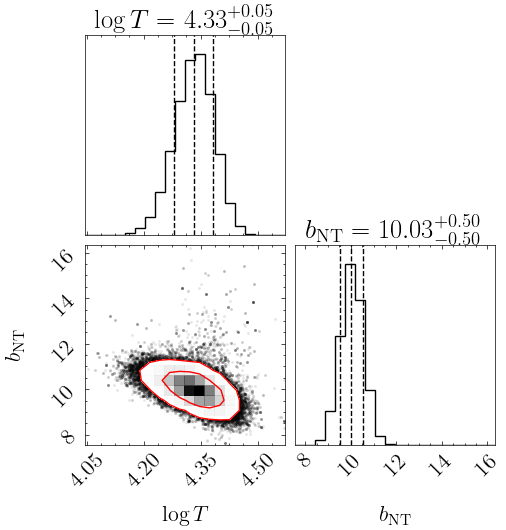

In [198]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [199]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

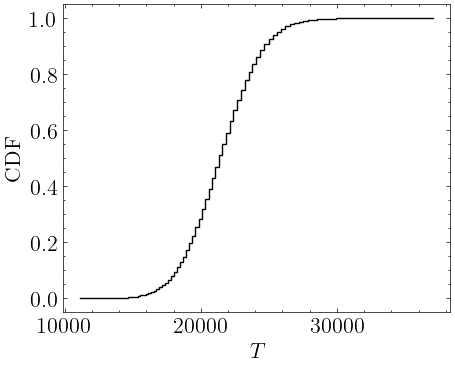

In [200]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [201]:
np.log10(ppf(cdf_3sig))

4.473433924076069

Predicted linewidths

In [202]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

13.785412641247756

In [203]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

11.417986047199012

In [204]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

11.229742247231068

In [205]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

11.087127272228535

In [206]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

10.876522947961215

In [207]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

10.737382454898903

In [208]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

10.669627383387244

In [209]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

10.645108211219714

In [210]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

10.570570781238771

In [211]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

10.343286482271015

# z=1.16, c2

In [212]:
b_list = [[['HI', 'H', 33, 3],
          ['CIV', 'C', 26, 3],
          ['OIV', 'O', 28, 12],
          ['OV', 'O', 27, 3]]]
          #['OVI', 'O', 45, 22]]]

In [213]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [214]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [215]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:03<00:00, 154.54it/s]


State([[ 4.5961837  23.26529927]
 [ 4.14382645 28.88341105]
 [ 4.65141545 25.08064445]
 [ 4.19706648 28.28416547]
 [ 4.57957037 24.17964454]
 [ 4.49700144 23.89346242]
 [ 4.47224483 27.02280788]
 [ 4.56722202 24.80637331]
 [ 4.124536   27.06655262]
 [ 4.44886993 27.96487141]
 [ 4.16276719 26.43553432]
 [ 4.40157785 24.89829354]
 [ 4.24467895 25.24547705]
 [ 4.45302097 29.17030071]
 [ 4.42422079 25.07032743]
 [ 4.55129236 26.27996708]
 [ 4.84014459 23.2901084 ]
 [ 4.59310734 23.75749802]
 [ 4.41213694 28.79572612]
 [ 4.22401139 26.5322434 ]
 [ 4.46348695 26.75492256]
 [ 4.20487748 24.43497588]
 [ 4.48712705 25.97821386]
 [ 4.43026739 25.12344562]
 [ 4.32459943 25.90512084]
 [ 4.5001497  28.67769043]
 [ 4.28224761 23.57117561]
 [ 4.35521022 26.0515472 ]
 [ 4.01437334 27.16879036]
 [ 4.26879135 24.43973641]
 [ 4.46461735 27.52718501]
 [ 4.36839702 23.27569245]
 [ 4.13411775 25.77382711]
 [ 4.40164564 27.10230623]
 [ 4.50379966 24.67085396]
 [ 4.04208362 28.03914159]
 [ 4.45175815 24.37670

In [216]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

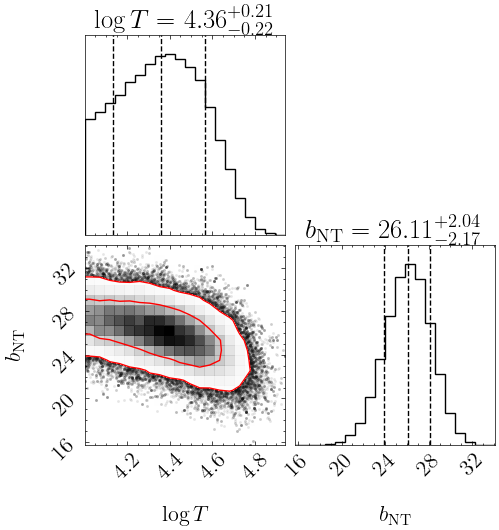

In [217]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [218]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

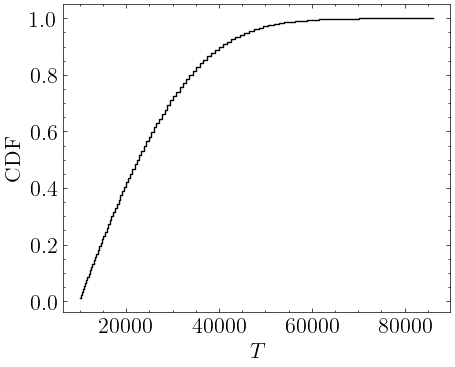

In [219]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [220]:
np.log10(ppf(cdf_3sig))

4.83537328287398

Predicted linewidths

In [221]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

27.980415852496815

In [222]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

26.725842917664302

In [223]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

26.6367723162639

In [224]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

26.57092797253792

In [231]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

26.472509602505554

In [232]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

26.41046373303604

In [233]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

26.380916383201907

In [234]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

26.370391364213777

In [235]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

26.338393760907397

In [236]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

26.239534349231665

# z=1.27, c1

In [237]:
b_list = [[['HI', 'H', 24, 3],
          ['CIII', 'C', 20, 12],
          ['CIV', 'C', 11.1, 0.2],
          ['NIV', 'N', 10, 6],
          ['OIII', 'O', 18, 6],
          ['OIV', 'O', 12, 1]]]

In [238]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [239]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [240]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:04<00:00, 117.05it/s]


State([[ 4.57455996  8.22865397]
 [ 4.34523257 10.09254351]
 [ 4.78454789  5.63988263]
 [ 4.57641347  8.81268089]
 [ 4.4754388   9.05312848]
 [ 4.42605998  9.46842059]
 [ 4.44940776  9.44039319]
 [ 4.56108079  8.77161741]
 [ 4.47741133  9.24269112]
 [ 4.27770795  9.73626156]
 [ 4.50258189  9.20074702]
 [ 4.50729486  8.8923565 ]
 [ 4.60795267  8.54853134]
 [ 4.40674982  9.28592316]
 [ 4.35791386 10.09972055]
 [ 4.26448989 10.05359883]
 [ 4.47978466  8.82749804]
 [ 4.58156297  8.56897525]
 [ 4.61324833  7.64756267]
 [ 4.38298192  9.26891444]
 [ 4.37304331  9.97015077]
 [ 4.41258251  9.46524547]
 [ 4.28995862  9.70442227]
 [ 4.48277117  9.08716661]
 [ 4.39156196  9.30917162]
 [ 4.04051393 10.47603294]
 [ 4.27260457 10.05987028]
 [ 4.45159394  8.90285999]
 [ 4.33083557  9.48058061]
 [ 4.26713941  9.7870001 ]
 [ 4.45527743  9.33855595]
 [ 4.26855953  9.97992996]
 [ 4.51053363  9.13498361]
 [ 4.35953501  9.81521921]
 [ 4.19605851 10.35021807]
 [ 4.52541501  9.01557371]
 [ 4.51130981  8.99003

In [241]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

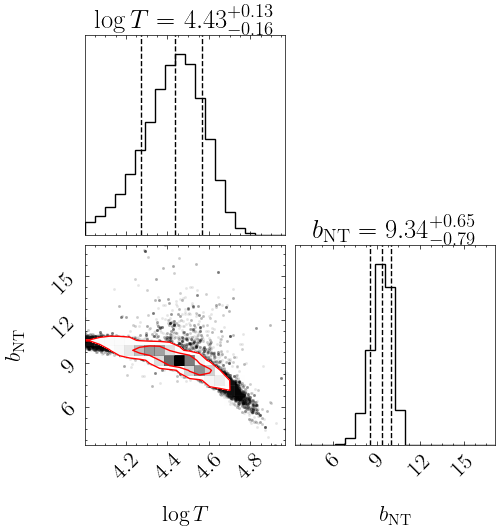

In [242]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Predicted linewidths

In [243]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

14.150084423037882

In [244]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

11.168928153371432

In [245]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

10.922722059003792

In [246]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

10.738001294328576

In [247]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

10.46289546474133

In [248]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

10.280530734619074

In [249]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

10.190362211032772

In [250]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

10.158320830662094

In [251]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

10.059627303561133

In [252]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

9.757582585849942

# z=1.27, c2

In [253]:
b_list = [[['HI', 'H', 37, 10],
          ['CIV', 'C', 9.8, 0.3],
          ['OIV', 'O', 11, 2]]]

In [254]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [255]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [256]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 195.07it/s]


State([[4.91730062 1.22333723]
 [4.79782432 3.02872209]
 [4.21350986 9.14835859]
 [4.55692966 6.77901938]
 [4.58103069 7.58522909]
 [4.69051508 4.70994601]
 [4.82051604 1.97848308]
 [4.0523094  8.70169116]
 [4.50583188 7.21608833]
 [4.6397898  6.35974467]
 [4.76394866 3.1550962 ]
 [4.75952245 4.18190921]
 [4.42553914 7.76221219]
 [4.81877805 3.32084128]
 [4.65538499 6.08334845]
 [4.59254902 7.32893312]
 [4.15817929 8.59203846]
 [4.77485173 3.61911997]
 [4.81177767 3.77077299]
 [4.69844783 4.93791   ]
 [4.60002508 6.91132753]
 [4.75251959 4.83914457]
 [4.72868104 4.42122966]
 [4.04691416 8.88448068]
 [4.42944575 8.07758165]
 [4.79381438 1.41627862]
 [4.9054507  2.05365683]
 [4.42533845 7.95478618]
 [4.54011988 6.9881505 ]
 [4.32747344 8.17115526]
 [4.85344867 1.83394762]
 [4.07060217 8.68331041]
 [4.85530713 2.34745695]
 [4.83755554 0.07926533]
 [4.72669462 4.37437451]
 [4.79492433 3.54140046]
 [4.84554548 0.16973693]
 [4.07815528 9.82111947]
 [4.80560856 3.67494889]
 [4.85148409 2.1028

In [257]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

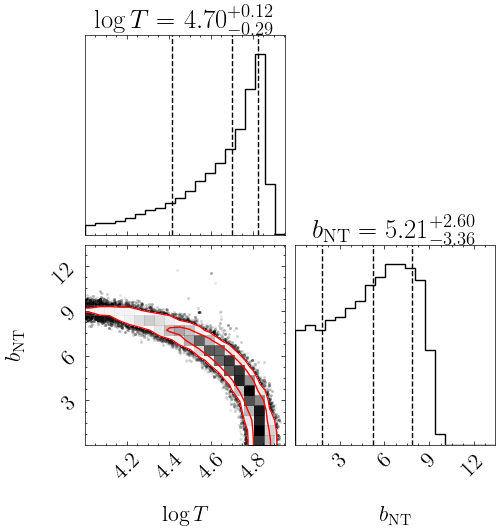

In [258]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [259]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

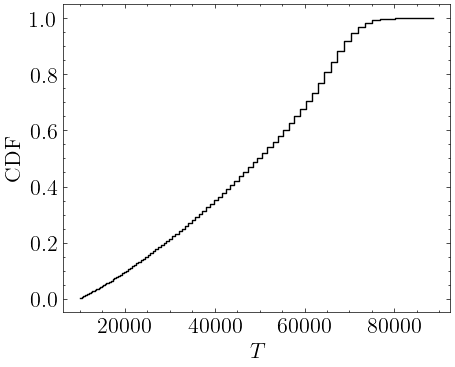

In [260]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [261]:
np.log10(ppf(cdf_3sig))

4.898302676483233

In [262]:
np.percentile(flat_samples['b_NT'], 100*cdf_3sig)

9.641051233823294

Predicted linewidths

In [263]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['He']))

15.37724357091142

In [264]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

9.86713896817735

In [265]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['N']))

9.365977482886219

In [266]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

8.95315712573851

In [268]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Ne']))

8.304435989563137

In [269]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Mg']))

7.863795747292576

In [270]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Al']))

7.641438916316469

In [274]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Si']))

7.561106632815019

In [275]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['S']))

7.309949779597184

In [276]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['Fe']))

6.49720994737811

# z=1.04, c3

In [184]:
b_list = [[['HI', 'H', 10, 2],
          ['CIV', 'C', 5.9, 0.4]]]
          #['OVI', 'O', 45, 22]]]

In [185]:
pos = np.array([4.2, 32]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [186]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(b_list)
)

In [187]:
sampler.run_mcmc(pos, 500, progress=True)

100%|████████████████████████████████████████| 500/500 [00:02<00:00, 240.48it/s]


State([[4.00283103 3.82406234]
 [4.04912318 4.33943036]
 [4.00249093 2.97686871]
 [4.09944735 3.29485831]
 [4.01068237 4.61265136]
 [4.01031802 3.76260352]
 [4.07330507 5.30393586]
 [4.0006084  5.12093933]
 [4.02509727 4.43671085]
 [4.02196805 4.65803946]
 [4.08532641 4.04895988]
 [4.0862001  3.0738338 ]
 [4.14800501 2.97593564]
 [4.00514767 3.70769613]
 [4.07715486 5.01441818]
 [4.03329639 5.18049647]
 [4.11259019 5.07356533]
 [4.03467282 5.32737863]
 [4.01504151 3.93701039]
 [4.06133045 5.11016817]
 [4.03191899 4.60004167]
 [4.01714146 4.67371735]
 [4.02901844 4.30418078]
 [4.08172455 3.39820814]
 [4.07118563 4.98522954]
 [4.03592385 3.88652181]
 [4.00938447 4.19808681]
 [4.0404496  4.47287425]
 [4.05168691 4.06869261]
 [4.01102115 5.56653441]
 [4.01445172 4.63540825]
 [4.0193857  4.5249917 ]
 [4.17987416 3.28011249]
 [4.01895288 4.941424  ]
 [4.04931527 4.31254599]
 [4.03911456 3.22066461]
 [4.0160328  3.65269366]
 [4.00949677 5.3715472 ]
 [4.05369914 4.18262001]
 [4.06550838 3.4866

In [188]:
flat_samples = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logT', 'b_NT'])

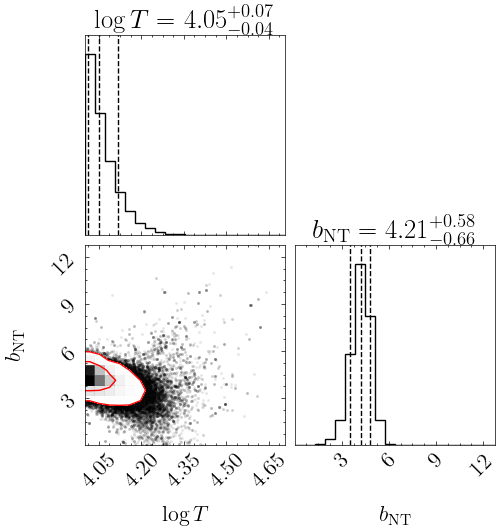

In [189]:
fig = corner.corner(
    flat_samples, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log T$', r'$b_{\mathrm{NT}}$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [190]:
pdf, edges = np.histogram(flat_samples['logT'], bins=100)
centers = .5*(edges[1:]+edges[:-1])
cdf = np.cumsum(pdf)/np.sum(pdf)
ppf = interpolate.interp1d(x=cdf, y=10**centers)

Text(0, 0.5, 'CDF')

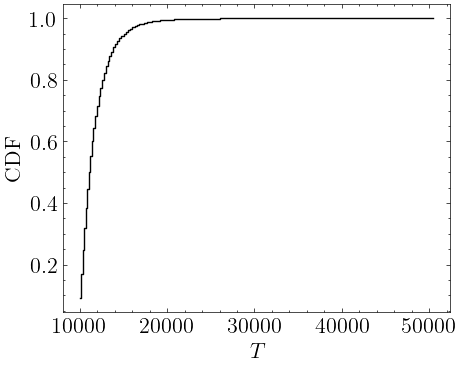

In [191]:
fig, ax = plt.subplots(1, figsize=(5,4))
ax.step(10**centers, cdf, where='mid')
ax.set_xlabel(r'$T$')
ax.set_ylabel('CDF')

In [192]:
np.log10(ppf(cdf_3sig))

4.392973093480249

Predicted linewidths

In [193]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['H']))

14.264223359621935

In [194]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['C']))

5.811103414139348

In [195]:
np.median(gen_b(flat_samples['logT'], flat_samples['b_NT'], A_dict['O']))

5.454841439369623